## Kernel SVM: Nonlinear Decision Boundaries via the Kernel Trick

0. Setup

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mglearn

from sklearn.svm import LinearSVC, SVC
from sklearn.datasets import make_blobs

Text(0, 0.5, 'feature2')

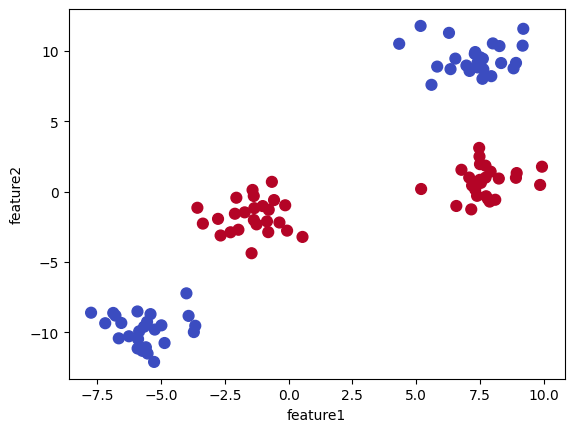

In [51]:
X, y = make_blobs(centers = 4, random_state=8)
y = y % 2
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap="coolwarm")
plt.xlabel("feature1")
plt.ylabel("feature2")

1. Build a linear model

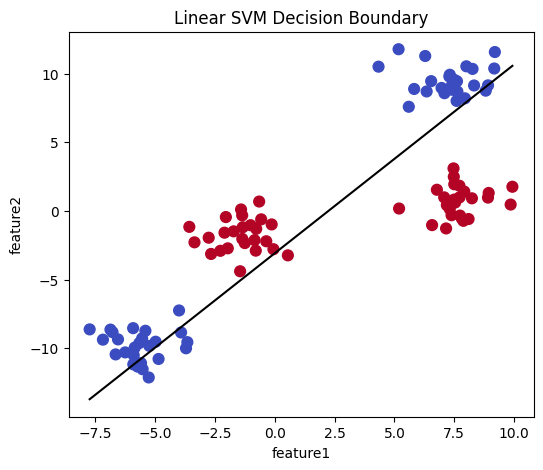

In [52]:
linear_svm = LinearSVC().fit(X, y)

w = linear_svm.coef_[0]
b = linear_svm.intercept_[0]
x_line = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_line = -(w[0] * x_line + b) / w[1]

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap="coolwarm")
plt.plot(x_line, y_line, color="black")
plt.xlabel("feature1")
plt.ylabel("feature2")
plt.title("Linear SVM Decision Boundary")

plt.show()

2. Feature mapping intuition

Do a simple engineered feature map:
\begin{align*}
z = x_2^2
\end{align*}



Text(0.5, 0, 'feature1 ** 2')

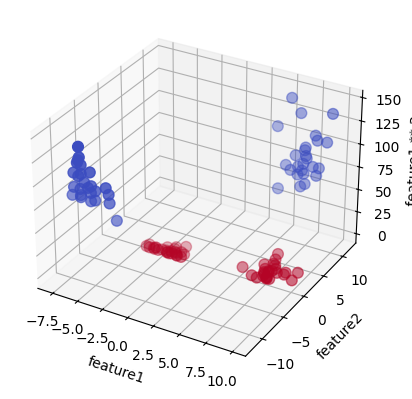

In [53]:
X_new = np.column_stack([X, X[:, 1] ** 2])

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(X_new[:, 0], X_new[:, 1], X_new[:, 2], c=y, cmap="coolwarm", s=60)
ax.set_xlabel("feature1")
ax.set_ylabel("feature2")
ax.set_zlabel("feature1 ** 2")

3. Kernel trick
- We don’t need to compute φ(x)
- We only need inner products φ(x)ᵀφ(x′)
- Kernel K(x, x′) computes that directly

Text(0.5, 0, 'feature1 ** 2')

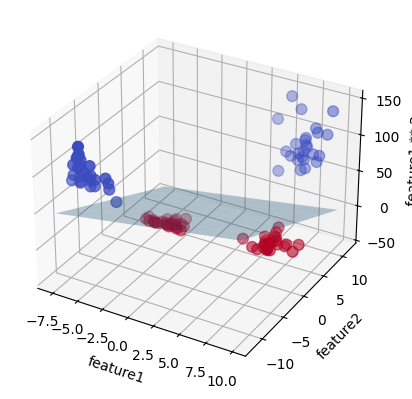

In [54]:
linear_svm_3d = LinearSVC().fit(X_new, y)
coef, intercept = linear_svm_3d.coef_[0], linear_svm_3d.intercept_

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
xx = np.linspace(X_new[:, 0].min(), X_new[:, 0].max(), 50)
yy = np.linspace(X_new[:, 1].min(), X_new[:, 1].max(), 50)

XX, YY = np.meshgrid(xx, yy)
ZZ = (coef[0] * XX + coef[1] * YY + intercept) / -coef[2]

ax.scatter(X_new[:, 0], X_new[:, 1], X_new[:, 2], c=y, cmap="coolwarm", s=60)
ax.plot_surface(XX, YY, ZZ, rstride=8, cstride=8, alpha=0.3)
ax.set_xlabel("feature1")
ax.set_ylabel("feature2")
ax.set_zlabel("feature1 ** 2")


4. Parameters C and gamma

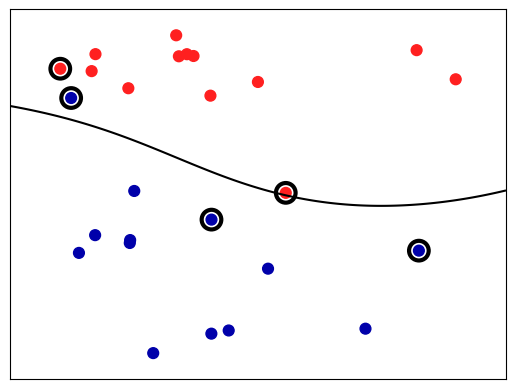

In [55]:
X, y = mglearn.tools.make_handcrafted_dataset()
svm = SVC(kernel="rbf", C=10, gamma=0.1).fit(X, y)
mglearn.plots.plot_2d_separator(svm, X, eps=.5)

plt.scatter(X[:, 0], X[:, 1], s=60, c=y, cmap=mglearn.cm2)
sv = svm.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=200, facecolors="none", edgecolors="black",
zorder=10, linewidth=3)


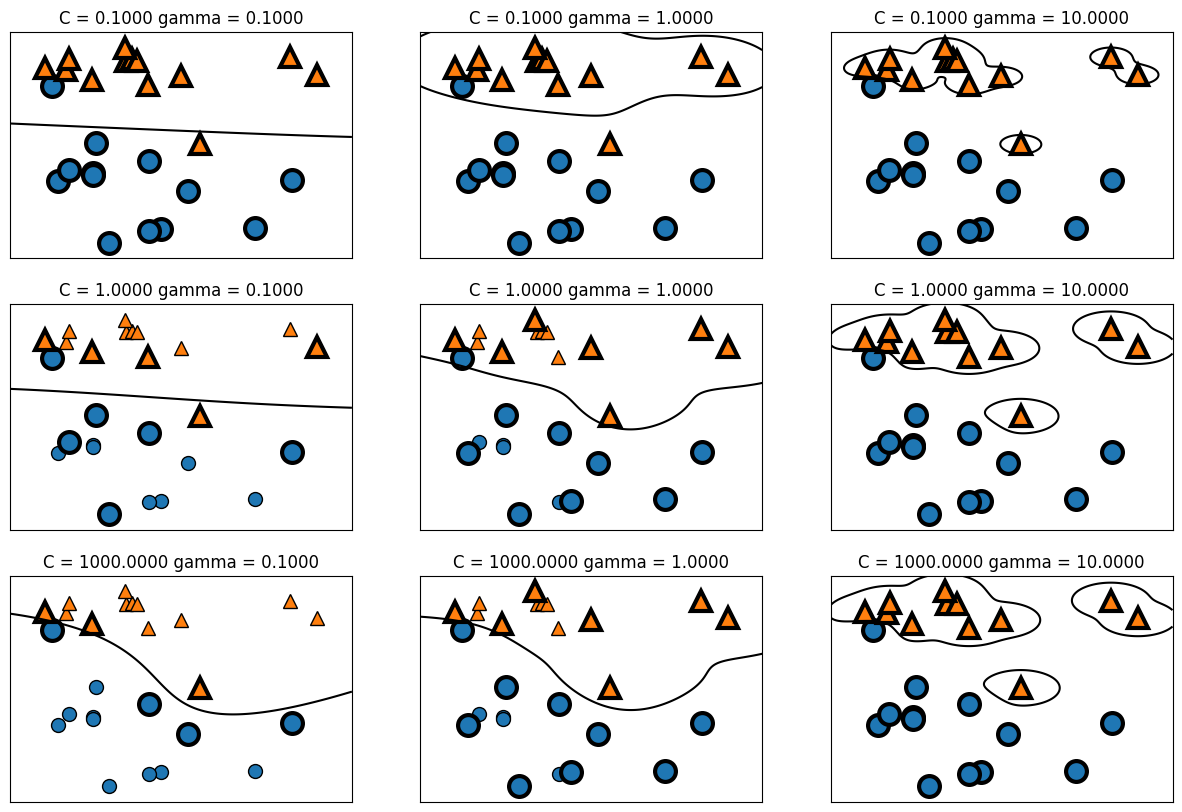

In [56]:
fig, axes = plt.subplots(3, 3, figsize = (15, 10))

for ax, C in zip(axes, [-1, 0, 3]):
 for a, gamma in zip(ax, range(-1, 2)):
     mglearn.plots.plot_svm(log_C=C, log_gamma=gamma, ax=a)

Effect of Hyperparameters in RBF SVM

C controls the penalty for misclassification:

- Small C → wider margin, stronger regularization, smoother boundary.
- Large C → narrower margin, weaker regularization, more flexible boundary.

Gamma controls the radius of influence of each support vector:

- Small gamma → wide influence → smooth decision boundary.
- Large gamma → localized influence → complex, highly curved boundary.